<a href="https://colab.research.google.com/github/shreyas284-crtl/Data-Science-Internship/blob/main/class28_Brain_MRI_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

100%|██████████| 15.1M/15.1M [00:00<00:00, 140MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/versions/1


**List sub directories**

In [ ]:
import os
print(os.listdir(path))

['yes', 'no', 'brain_tumor_dataset']


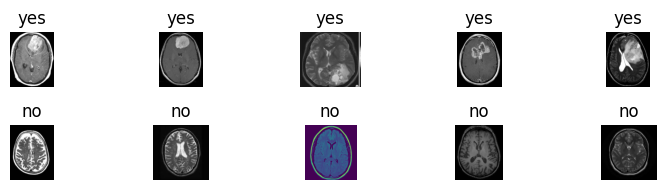

In [ ]:
# creating path for yes/No  folder
import matplotlib.pyplot as plt
from PIL import Image
i=1
plt.figure(figsize=(8,2))
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      img_path = os.path.join(class_path,img)
      if os.path.isfile(img_path):
        img = Image.open(img_path)
        plt.subplot(2,5,i)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        i+=1
plt.tight_layout()
plt.show()



In [ ]:
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,count)

yes 155
no 98
brain_tumor_dataset 2


In [ ]:
# create dataframe , labels
df =[]
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)
    for img in images:
      img_path = os.path.join(class_path,img)
      if os.path.isfile(img_path):
        df.append([img_path,class_name])

In [ ]:
import pandas as pd
data = pd.DataFrame(df,columns=['img_path','labels'])

In [ ]:
data

,img_path,labels
0,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
1,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
2,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
3,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
4,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
...,...,...
248,/root/.cache/kagglehub/datasets/navoneel/brain...,no
249,/root/.cache/kagglehub/datasets/navoneel/brain...,no
250,/root/.cache/kagglehub/datasets/navoneel/brain...,no
251,/root/.cache/kagglehub/datasets/navoneel/brain...,no


In [ ]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
data

,img_path,labels
0,/root/.cache/kagglehub/datasets/navoneel/brain...,no
1,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
2,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
3,/root/.cache/kagglehub/datasets/navoneel/brain...,no
4,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
...,...,...
248,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
249,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
250,/root/.cache/kagglehub/datasets/navoneel/brain...,yes
251,/root/.cache/kagglehub/datasets/navoneel/brain...,no


In [ ]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = int(0.15*len(df))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = data.iloc[:train_size]
# df.iloc[:,52500]
val_data = data.iloc[train_size:train_size + val_size]
# df.iloc[52500:52500+11250]
test_data = data.iloc[train_size + val_size:]
# df.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:177 -----val_size:37----test_size:37
Training set size: 177
Validation set size: 37
Test set size: 39


In [ ]:
image_path = data["img_path"][0]
image = Image.open(image_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(234, 215)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, # Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 177 validated image filenames belonging to 2 classes.


In [ ]:
# train data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 39 validated image filenames belonging to 2 classes.


In [ ]:
# train data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 37 validated image filenames belonging to 2 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 6)
Train Label Shape: (32, 2)

Validation Shape: (5, 224, 224, 3) (Batches = 2)
Validation Label Shape: (5, 2)

Test Shape: (32, 224, 224, 3) (Batches = 2)
Test Label Shape: (32, 2)



In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy

In [ ]:
n_classes= 2
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='sigmoid')])

In [ ]:
cnn_model.compile(loss=binary_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [ ]:
Cnn = cnn_model.fit(train_generator,
                    epochs=20,validation_data=val_generator,
                    verbose=1)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5650 - loss: 0.7356 - val_accuracy: 0.4865 - val_loss: 0.6886
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6384 - loss: 0.6644 - val_accuracy: 0.5135 - val_loss: 0.6998
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6328 - loss: 0.6375 - val_accuracy: 0.5135 - val_loss: 0.7236
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6441 - loss: 0.6182 - val_accuracy: 0.6216 - val_loss: 0.6825
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6993 - loss: 0.6129

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

In [ ]:
# Retrieve metrics from the training history
acc = Cnn.history['accuracy']
val_acc = Cnn.history['val_accuracy']
loss = Cnn.history['loss']
val_loss = Cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "three.jpg"

# Load image
img = image.load_img(img_path, target_size=(128, 128))  # same as training

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = cnn_model.predict(img_array)
prediction

In [ ]:
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)